# Análisis país–clase desde el GPKG final del scoring

Este notebook trabaja **solo desde el GeoPackage final** del Módulo 10.

Objetivo: identificar combinaciones país–clase con:

1. **Baja cantidad de puntos / grupos XY**.
2. **Bajo scoring de aptitud**.

Basicamente buscamos que clases tienen bajo scoring y además baja cantidad de registros


In [36]:
from pathlib import Path
from typing import Optional

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, clear_output
except Exception:
    display = print

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("ipywidgets disponible:", HAS_WIDGETS)


ipywidgets disponible: True


## 1. Configuración

In [37]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_DIR = Path(r"C:/Users/jesus/Work/CR/Github/PGBM_actividad_1_diagnostico")

GPKG_PATH = PROJECT_DIR / "data/processed/scoring_aptitud/10_scoring_aptitud_outputs.gpkg"

# Si conoce el nombre exacto de la capa, colóquelo aquí.
# Si queda como None, se selecciona automáticamente la primera capa con país y clase.
LAYER_NAME: Optional[str] = None

OUT_TABLES = PROJECT_DIR / "outputs/tables"
OUT_FIGURES = PROJECT_DIR / "outputs/figures"

OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)

# Umbrales simples para cantidad de puntos/grupos XY.
# n_xy < COUNT_CRITICAL  => baja cantidad de puntos crítica
# n_xy < COUNT_LOW       => baja cantidad de puntos
# n_xy >= COUNT_LOW      => suficiente
COUNT_CRITICAL = 50
COUNT_LOW = 200

# Umbrales simples para score de aptitud.
SCORE_CRITICAL = 70
SCORE_LOW = 80

TOP_N = 30

print("GPKG:", GPKG_PATH)
print("Existe:", GPKG_PATH.exists())
print("Tablas:", OUT_TABLES)
print("Figuras:", OUT_FIGURES)


GPKG: C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\data\processed\scoring_aptitud\10_scoring_aptitud_outputs.gpkg
Existe: True
Tablas: C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\tables
Figuras: C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\figures


## 2. Leer GPKG y detectar columnas

In [38]:
# ============================================================
# COLUMNAS CANDIDATAS
# ============================================================

COUNTRY_CANDIDATES = [
    "pais_dominante", "pais_grupo", "pais", "Pais", "País", "Pais_es", "PAIS", "country"
]

LEVEL_1_CANDIDATES = [
    "nivel_1_dominante", "Nivel_1", "nivel_1", "nivel1", "Nivel1"
]

LEVEL_2_CANDIDATES = [
    "nivel_2_dominante", "Nivel_2", "nivel_2", "nivel2", "Nivel2"
]

SCORE_CANDIDATES = [
    "score_aptitud_total", "score_aptitud_raw", "score_total", "score_final", "score_aptitud", "score"
]

GROUP_ID_CANDIDATES = [
    "xy_group_id", "id_xy", "xy_id", "grupo_xy", "group_id"
]

N_RECORDS_CANDIDATES = [
    "n_registros", "n_registros_subset", "n_registros_original"
]


def find_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> Optional[str]:
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for cand in candidates:
        if cand in cols:
            return cand

    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise ValueError(
            "No se encontró ninguna columna candidata: "
            + ", ".join(candidates)
            + "\nColumnas disponibles:\n"
            + "\n".join(map(str, df.columns))
        )
    return None


def list_layers(gpkg_path: Path) -> list[str]:
    try:
        import pyogrio
        info = pyogrio.list_layers(gpkg_path)
        return [row[0] for row in info]
    except Exception:
        import fiona
        return list(fiona.listlayers(gpkg_path))


def read_layer(gpkg_path: Path, layer: str) -> pd.DataFrame:
    try:
        import pyogrio
        return pd.DataFrame(pyogrio.read_dataframe(gpkg_path, layer=layer, read_geometry=False))
    except Exception:
        import geopandas as gpd
        gdf = gpd.read_file(gpkg_path, layer=layer)
        return pd.DataFrame(gdf.drop(columns="geometry", errors="ignore"))


def auto_read_gpkg(gpkg_path: Path, layer_name: Optional[str] = None) -> tuple[str, pd.DataFrame]:
    if layer_name:
        return layer_name, read_layer(gpkg_path, layer_name)

    layers = list_layers(gpkg_path)
    print("Capas disponibles:")
    for layer in layers:
        print(" -", layer)

    for layer in layers:
        df_test = read_layer(gpkg_path, layer)
        country = find_col(df_test, COUNTRY_CANDIDATES, required=False)
        l1 = find_col(df_test, LEVEL_1_CANDIDATES, required=False)
        l2 = find_col(df_test, LEVEL_2_CANDIDATES, required=False)

        if country and (l1 or l2):
            print("Capa seleccionada:", layer)
            return layer, df_test

    raise ValueError("No se encontró una capa con país y clase.")


def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("%", "", regex=False),
        errors="coerce",
    )


layer_name, df = auto_read_gpkg(GPKG_PATH, LAYER_NAME)

country_col = find_col(df, COUNTRY_CANDIDATES)
level1_col = find_col(df, LEVEL_1_CANDIDATES, required=False)
level2_col = find_col(df, LEVEL_2_CANDIDATES, required=False)
score_col = find_col(df, SCORE_CANDIDATES)
group_col = find_col(df, GROUP_ID_CANDIDATES)
n_records_col = find_col(df, N_RECORDS_CANDIDATES, required=False)

print("\nCapa:", layer_name)
print("Filas:", f"{len(df):,}")
print("País:", country_col)
print("Nivel_1:", level1_col)
print("Nivel_2:", level2_col)
print("Score:", score_col)
print("Grupo XY:", group_col)
print("n_registros:", n_records_col)

display(df.head())


Capas disponibles:
 - xy_group_aptitude_master
 - review_priority_cases
 - record_aptitude_flags
 - source_aptitude_ranking
 - gap_priority_country_class
 - selection_scenarios_summary
 - scoring_audit_summary
 - category_definitions
 - source_category_definitions
Capa seleccionada: xy_group_aptitude_master

Capa: xy_group_aptitude_master
Filas: 1,111,850
País: pais_dominante
Nivel_1: nivel_1_dominante
Nivel_2: nivel_2_dominante
Score: score_aptitud_total
Grupo XY: xy_group_id
n_registros: n_registros


,xy_group_id,lon,lat,pais_grupo,estado_xy_subset,tipo_grupo_original,n_registros_original,n_registros_subset,n_registros,n_fuentes,...,score_fuente,score_aptitud_raw,score_cap,cap_reason,score_aptitud_total,categoria_aptitud_preliminar,categoria_uso_actividad_1_8,definicion_categoria_aptitud,accion_recomendada,razon_categoria_aptitud
0,XY_000000000001,-94.103333,16.500333,México,xy_unico_en_subset,xy_unico,1,1,1.0,1.0,...,70.0,82.3,100.0,,82.3,datos_para_validacion,validación,Datos con aptitud buena pero no máxima; pueden...,Usar preferentemente para validación estratifi...,score:82.3; tipo_xy:xy_unico_en_subset; alerta...
1,XY_000000000002,-94.102972,16.500500,México,xy_unico_en_subset,xy_unico,1,1,1.0,1.0,...,70.0,82.3,100.0,,82.3,datos_para_validacion,validación,Datos con aptitud buena pero no máxima; pueden...,Usar preferentemente para validación estratifi...,score:82.3; tipo_xy:xy_unico_en_subset; alerta...
2,XY_000000000003,-94.102972,16.500917,México,xy_unico_en_subset,xy_unico,1,1,1.0,1.0,...,70.0,82.3,100.0,,82.3,datos_para_validacion,validación,Datos con aptitud buena pero no máxima; pueden...,Usar preferentemente para validación estratifi...,score:82.3; tipo_xy:xy_unico_en_subset; alerta...
3,XY_000000000004,-94.102639,16.500306,México,xy_unico_en_subset,xy_unico,1,1,1.0,1.0,...,70.0,82.3,100.0,,82.3,datos_para_validacion,validación,Datos con aptitud buena pero no máxima; pueden...,Usar preferentemente para validación estratifi...,score:82.3; tipo_xy:xy_unico_en_subset; alerta...
4,XY_000000000015,-94.056972,18.126056,México,xy_unico_en_subset,xy_unico,1,1,1.0,1.0,...,70.0,82.3,100.0,,82.3,datos_para_validacion,validación,Datos con aptitud buena pero no máxima; pueden...,Usar preferentemente para validación estratifi...,score:82.3; tipo_xy:xy_unico_en_subset; alerta...


## 3. Preparar tabla base

Cada fila representa una unidad del GPKG final. Se usa `xy_group_id` para contar grupos XY. Si existe `n_registros`, se usa como conteo de registros asociados; si no existe, cada grupo cuenta como 1.


In [39]:
base = df.copy()

base["_pais"] = base[country_col].map(clean_text)
base["_score"] = clean_numeric(base[score_col])
base["_xy"] = base[group_col].astype(str)

if n_records_col:
    base["_n_registros"] = clean_numeric(base[n_records_col]).fillna(1)
else:
    base["_n_registros"] = 1

if level1_col:
    base["_nivel_1"] = base[level1_col].map(clean_text)

if level2_col:
    base["_nivel_2"] = base[level2_col].map(clean_text)

base = base[base["_pais"] != ""].copy()

print("Base limpia:", base.shape)
display(base[["_pais", "_score", "_xy", "_n_registros"]].head())


Base limpia: (1111193, 83)


,_pais,_score,_xy,_n_registros
0,México,82.3,XY_000000000001,1.0
1,México,82.3,XY_000000000002,1.0
2,México,82.3,XY_000000000003,1.0
3,México,82.3,XY_000000000004,1.0
4,México,82.3,XY_000000000015,1.0


## 4. Funciones: baja cantidad de puntos y bajo scoring

In [40]:
def count_status(n_xy: int) -> str:
    if n_xy < COUNT_CRITICAL:
        return "baja cantidad de puntos critica"
    if n_xy < COUNT_LOW:
        return "baja cantidad de puntos"
    return "suficiente"


def score_status(score: float) -> str:
    if pd.isna(score):
        return "sin score"
    if score < SCORE_CRITICAL:
        return "score critico"
    if score < SCORE_LOW:
        return "score bajo"
    return "suficiente"


def build_count_gaps(base: pd.DataFrame, level_col_internal: str) -> pd.DataFrame:
    work = base[["_pais", level_col_internal, "_xy", "_n_registros"]].copy()
    work = work[work[level_col_internal] != ""].copy()
    work = work.rename(columns={level_col_internal: "clase"})

    countries = sorted(work["_pais"].unique())
    classes = sorted(work["clase"].unique())

    grid = pd.MultiIndex.from_product(
        [countries, classes],
        names=["pais", "clase"],
    ).to_frame(index=False)

    observed = (
        work.groupby(["_pais", "clase"], as_index=False)
        .agg(
            n_xy=("_xy", "nunique"),
            n_registros=("_n_registros", "sum"),
        )
        .rename(columns={"_pais": "pais"})
    )

    out = grid.merge(observed, on=["pais", "clase"], how="left")
    out["n_xy"] = out["n_xy"].fillna(0).astype(int)
    out["n_registros"] = out["n_registros"].fillna(0).round(0).astype(int)

    regional = (
        work.groupby("clase", as_index=False)
        .agg(n_xy_regional=("_xy", "nunique"))
    )
    out = out.merge(regional, on="clase", how="left")

    country_total = (
        work.groupby("_pais", as_index=False)
        .agg(n_xy_pais_total=("_xy", "nunique"))
        .rename(columns={"_pais": "pais"})
    )
    out = out.merge(country_total, on="pais", how="left")

    out["pct_clase_en_pais"] = np.where(
        out["n_xy_pais_total"] > 0,
        100 * out["n_xy"] / out["n_xy_pais_total"],
        0,
    ).round(3)

    out["estado_count"] = out["n_xy"].apply(count_status)

    # Campo de interpretación más claro para reporte.
    out["lectura_count"] = np.where(
        out["n_xy"] == 0,
        "baja cantidad de puntos: no hay grupos XY en el pais",
        np.where(
            out["n_xy"] < COUNT_LOW,
            "baja cantidad de puntos",
            "suficiente"
        )
    )

    # Orden: menor n_xy primero; cuando n_xy = 0, prioriza clases regionalmente importantes.
    out["prioridad_count"] = np.where(
        out["n_xy"] == 0,
        out["n_xy_regional"],
        COUNT_LOW - out["n_xy"]
    )

    out = out.sort_values(
        ["n_xy", "prioridad_count", "n_xy_regional"],
        ascending=[True, False, False],
    ).reset_index(drop=True)

    return out


def build_score_gaps(base: pd.DataFrame, level_col_internal: str) -> pd.DataFrame:
    work = base[["_pais", level_col_internal, "_xy", "_n_registros", "_score"]].copy()
    work = work[work[level_col_internal] != ""].copy()
    work = work.rename(columns={level_col_internal: "clase"})

    out = (
        work.groupby(["_pais", "clase"], as_index=False)
        .agg(
            n_xy=("_xy", "nunique"),
            n_registros=("_n_registros", "sum"),
            score_medio=("_score", "mean"),
            score_min=("_score", "min"),
        )
        .rename(columns={"_pais": "pais"})
    )

    out["n_registros"] = out["n_registros"].round(0).astype(int)
    out["score_medio"] = out["score_medio"].round(3)
    out["score_min"] = out["score_min"].round(3)
    out["estado_score"] = out["score_medio"].apply(score_status)

    out = out.sort_values(
        ["score_medio", "n_xy"],
        ascending=[True, True],
    ).reset_index(drop=True)

    return out


## 5. Generar y exportar tablas finales

In [41]:
count_gaps = {}
score_gaps = {}

levels = {}
if level1_col:
    levels["Nivel_1"] = "_nivel_1"
if level2_col:
    levels["Nivel_2"] = "_nivel_2"

for level_name, level_internal in levels.items():
    count_gaps[level_name] = build_count_gaps(base, level_internal)
    score_gaps[level_name] = build_score_gaps(base, level_internal)

    out_count = OUT_TABLES / f"10_baja_cantidad_puntos_pais_clase_{level_name}.csv"
    out_score = OUT_TABLES / f"10_bajo_scoring_pais_clase_{level_name}.csv"

    count_gaps[level_name].to_csv(out_count, index=False, encoding="utf-8-sig")
    score_gaps[level_name].to_csv(out_score, index=False, encoding="utf-8-sig")

    print("[OK]", out_count)
    print("[OK]", out_score)

    print("\n", level_name, "· Baja cantidad de puntos")
    display(count_gaps[level_name].head(20))

    print("\n", level_name, "· Bajo scoring")
    display(score_gaps[level_name].head(20))


[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\tables\10_baja_cantidad_puntos_pais_clase_Nivel_1.csv
[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\tables\10_bajo_scoring_pais_clase_Nivel_1.csv

 Nivel_1 · Baja cantidad de puntos


,pais,clase,n_xy,n_registros,n_xy_regional,n_xy_pais_total,pct_clase_en_pais,estado_count,lectura_count,prioridad_count
0,Nicaragua,31 Cultivos intensivos No-Arbóreos,0,0,329113,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,329113
1,Belice,32 Cultivos Arbóreos,0,0,271085,33319,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,271085
2,México,32 Cultivos Arbóreos,0,0,271085,2149,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,271085
3,Nicaragua,41 Bosque latifoliado y mixto,0,0,241990,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,241990
4,Nicaragua,11 Urbano,0,0,29275,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,29275
5,Costa Rica,42 Bosque de coníferas,0,0,13442,133066,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,13442
6,Nicaragua,42 Bosque de coníferas,0,0,13442,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,13442
7,Panamá,42 Bosque de coníferas,0,0,13442,29187,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,13442
8,Costa Rica,43 Manglares,0,0,11916,133066,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,11916
9,Nicaragua,43 Manglares,0,0,11916,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,11916



 Nivel_1 · Bajo scoring


,pais,clase,n_xy,n_registros,score_medio,score_min,estado_score
0,Costa Rica,12 Otras tierras,9,9,65.000,65.00,score critico
1,Costa Rica,21 Cuerpos de Agua,5,5,66.600,66.60,score critico
2,Nicaragua,32 Cultivos Arbóreos,1,1,68.850,68.85,score critico
3,México,11 Urbano,5,6,71.160,60.00,score bajo
4,Belice,12 Otras tierras,72,72,71.895,60.00,score bajo
5,Costa Rica,11 Urbano,438,438,72.692,60.00,score bajo
6,Nicaragua,21 Cuerpos de Agua,3,15,73.717,60.00,score bajo
7,Costa Rica,91 Otras,5175,5479,74.571,60.00,score bajo
8,El Salvador,12 Otras tierras,4625,4634,74.585,70.00,score bajo
9,Honduras,12 Otras tierras,154,186,74.643,70.00,score bajo


[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\tables\10_baja_cantidad_puntos_pais_clase_Nivel_2.csv
[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\tables\10_bajo_scoring_pais_clase_Nivel_2.csv

 Nivel_2 · Baja cantidad de puntos


,pais,clase,n_xy,n_registros,n_xy_regional,n_xy_pais_total,pct_clase_en_pais,estado_count,lectura_count,prioridad_count
0,Belice,410 Bosque latifoliado y mixto,0,0,223389,33319,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,223389
1,Nicaragua,410 Bosque latifoliado y mixto,0,0,223389,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,223389
2,Belice,321 Café,0,0,218343,33319,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,218343
3,México,321 Café,0,0,218343,2149,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,218343
4,Costa Rica,315 Otros cultivos intensivos no arbóreos,0,0,116816,133066,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,116816
5,Nicaragua,315 Otros cultivos intensivos no arbóreos,0,0,116816,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,116816
6,Costa Rica,313 Caña de azúcar,0,0,104091,133066,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,104091
7,México,313 Caña de azúcar,0,0,104091,2149,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,104091
8,Nicaragua,313 Caña de azúcar,0,0,104091,7,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,104091
9,El Salvador,311 Palma aceitera,0,0,77460,570957,0.0,baja cantidad de puntos critica,baja cantidad de puntos: no hay grupos XY en e...,77460



 Nivel_2 · Bajo scoring


,pais,clase,n_xy,n_registros,score_medio,score_min,estado_score
0,Costa Rica,"122 Suelo desnudo, arena, rocoso, lava, otros",9,9,65.000,65.00,score critico
1,Costa Rica,210 Cuerpos de Agua,5,5,66.600,66.60,score critico
2,Nicaragua,321 Café,1,1,68.850,68.85,score critico
3,México,442 Plantaciones forestales,4,4,68.850,68.85,score critico
4,Costa Rica,412 Latifoliado secundario húmedo,856,856,70.000,70.00,score bajo
5,México,110 Urbano,5,6,71.160,60.00,score bajo
6,Belice,"122 Suelo desnudo, arena, rocoso, lava, otros",21,21,71.457,60.00,score bajo
7,Belice,121 Otros artificializado,51,51,72.075,69.30,score bajo
8,Costa Rica,110 Urbano,438,438,72.692,60.00,score bajo
9,Nicaragua,210 Cuerpos de Agua,3,15,73.717,60.00,score bajo


## 6. Gráficos estáticos corregidos

Para **baja cantidad de puntos**, si una combinación país–clase tiene `n_xy = 0`, el gráfico usa `n_xy_regional` como valor de priorización visual. Así se evita una barra invisible y se muestra si la clase existe regionalmente pero está ausente en el país.


[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\figures\10_baja_cantidad_puntos_top30_Nivel_1.png


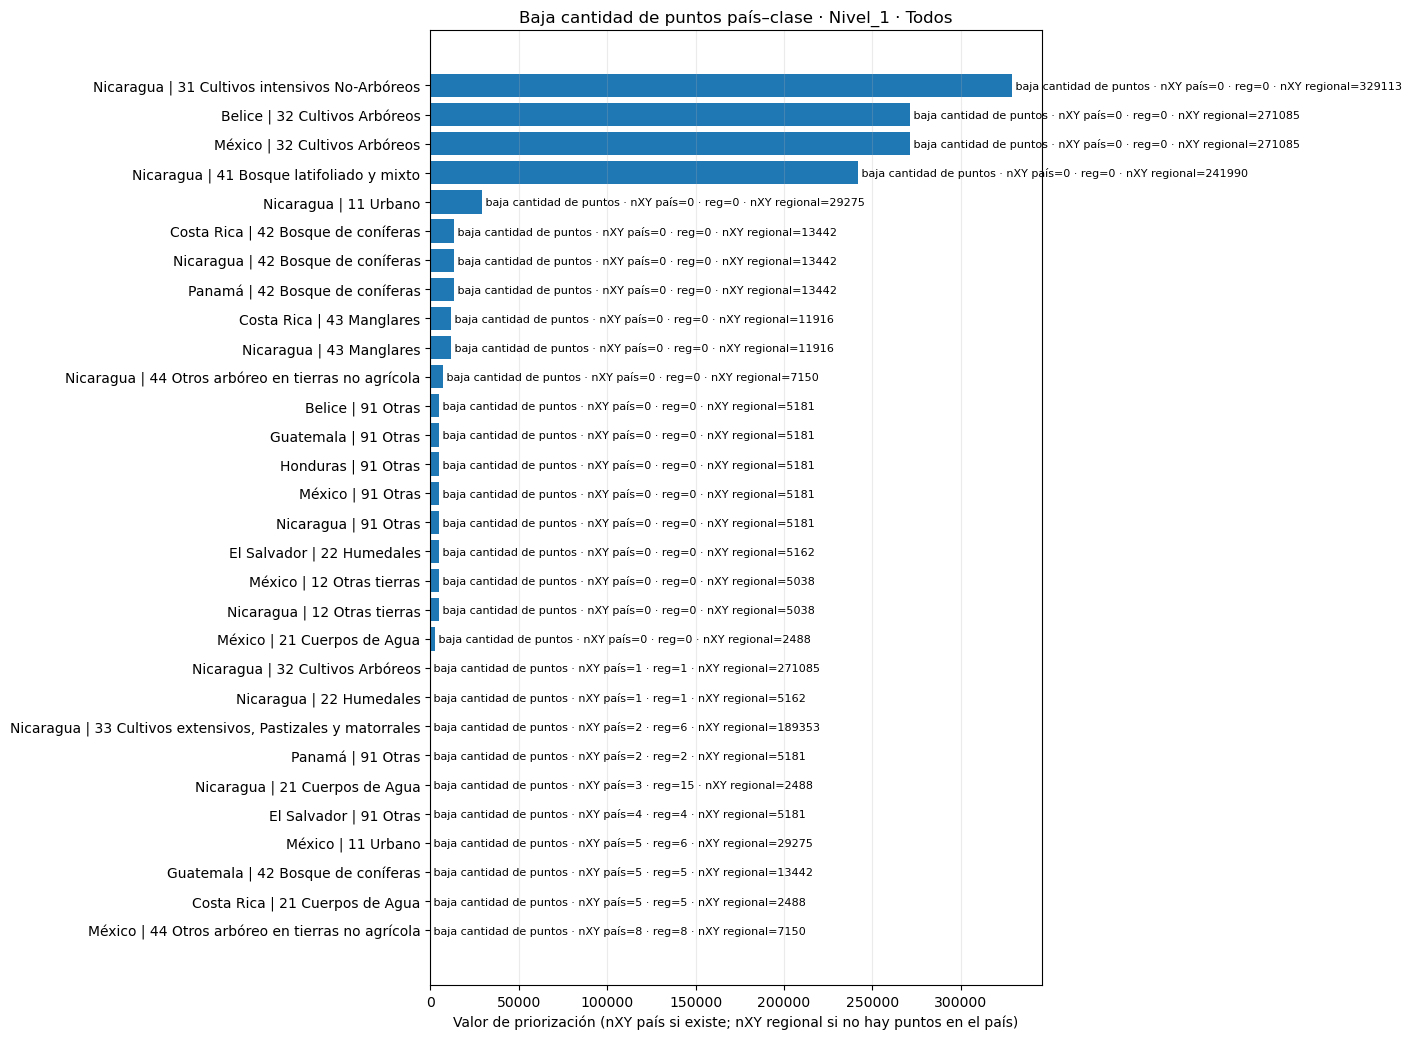

[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\figures\10_bajo_scoring_top30_Nivel_1.png


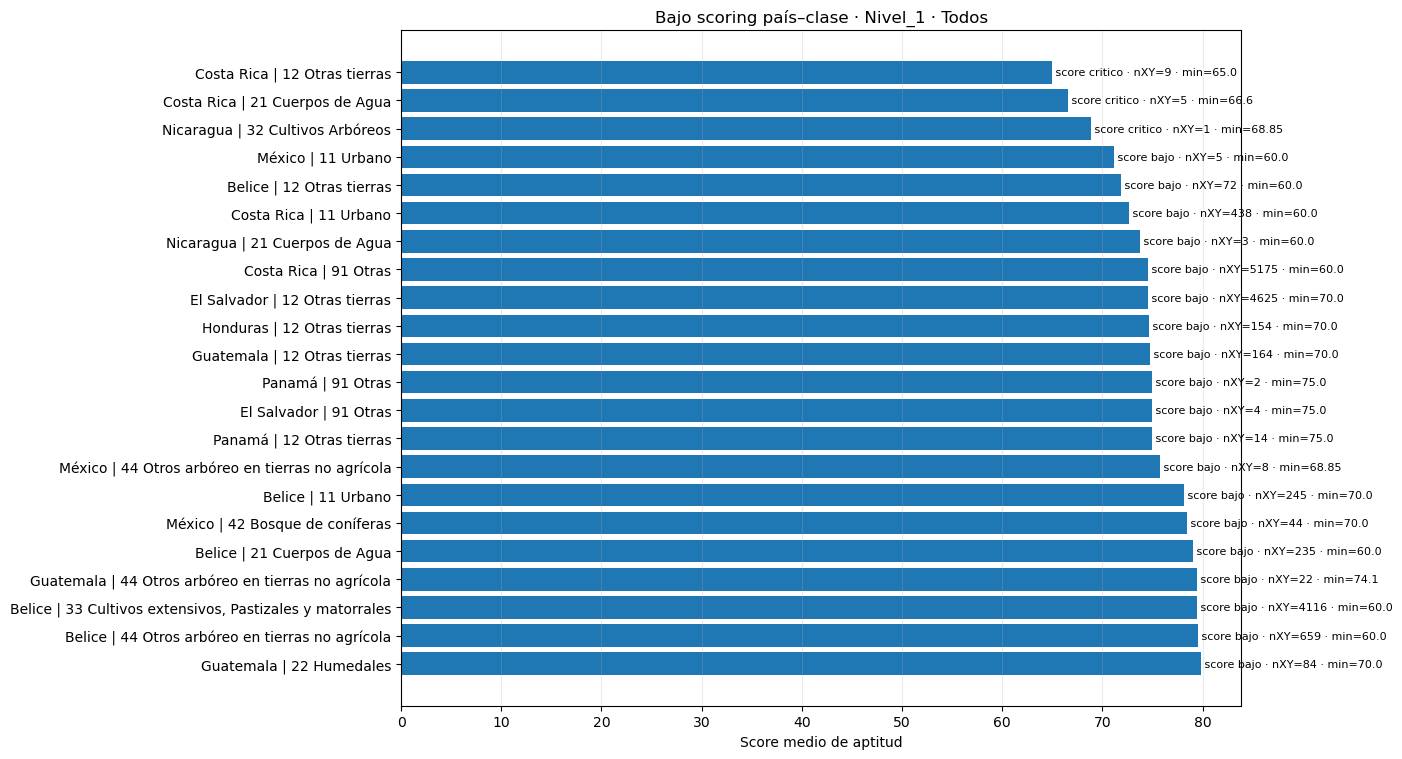

[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\figures\10_baja_cantidad_puntos_top30_Nivel_2.png


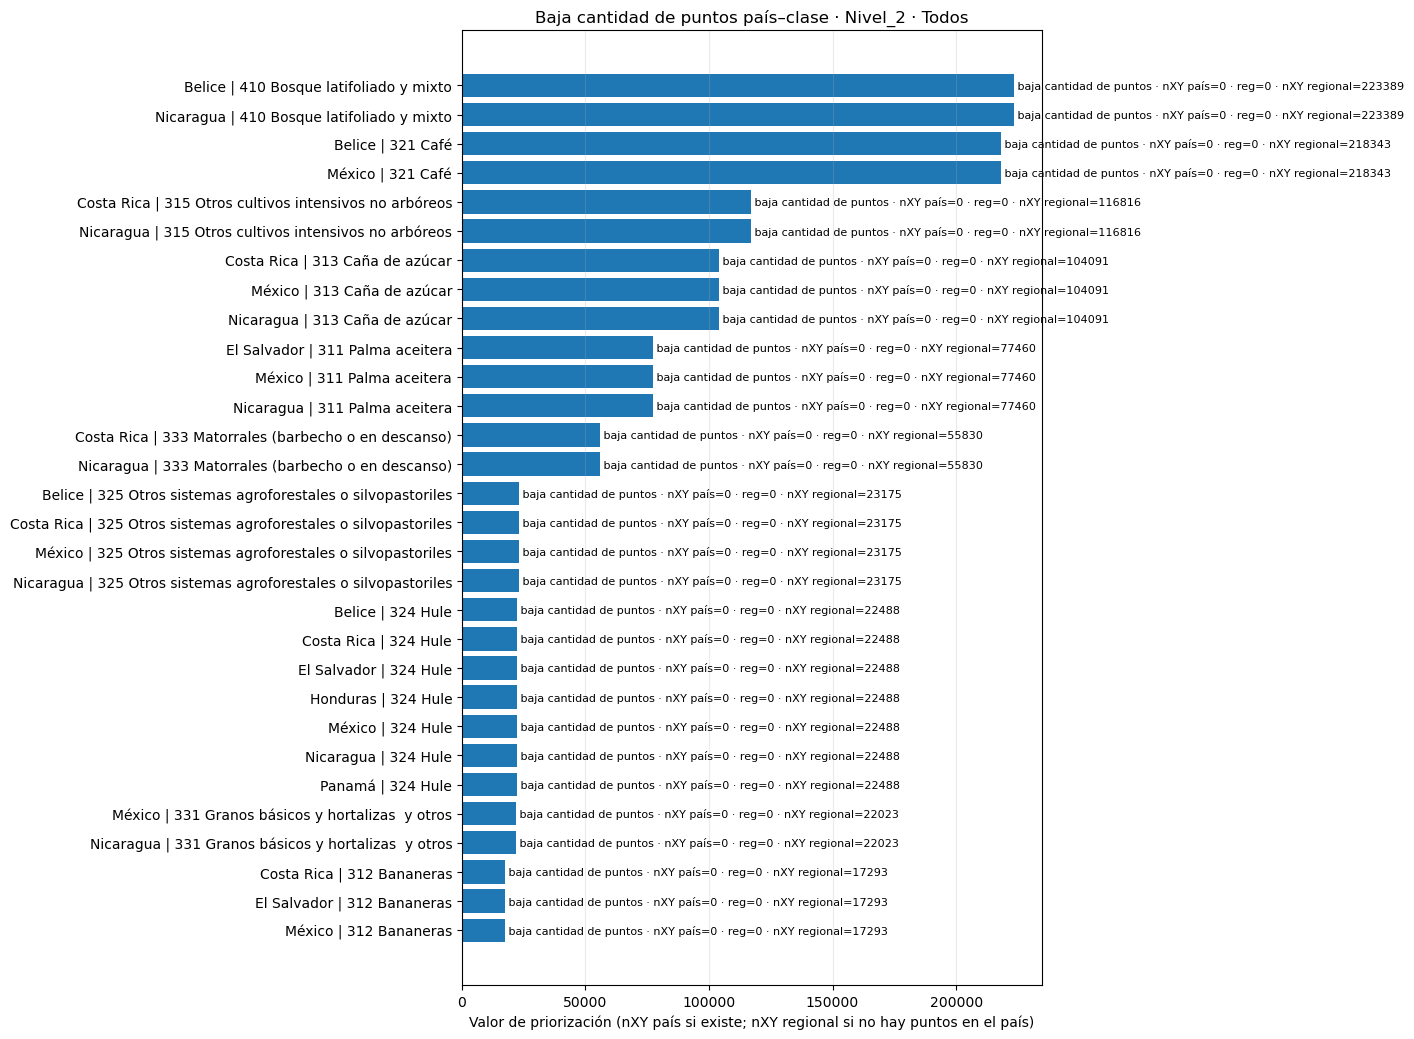

[OK] C:\Users\jesus\Work\CR\Github\PGBM_actividad_1_diagnostico\outputs\figures\10_bajo_scoring_top30_Nivel_2.png


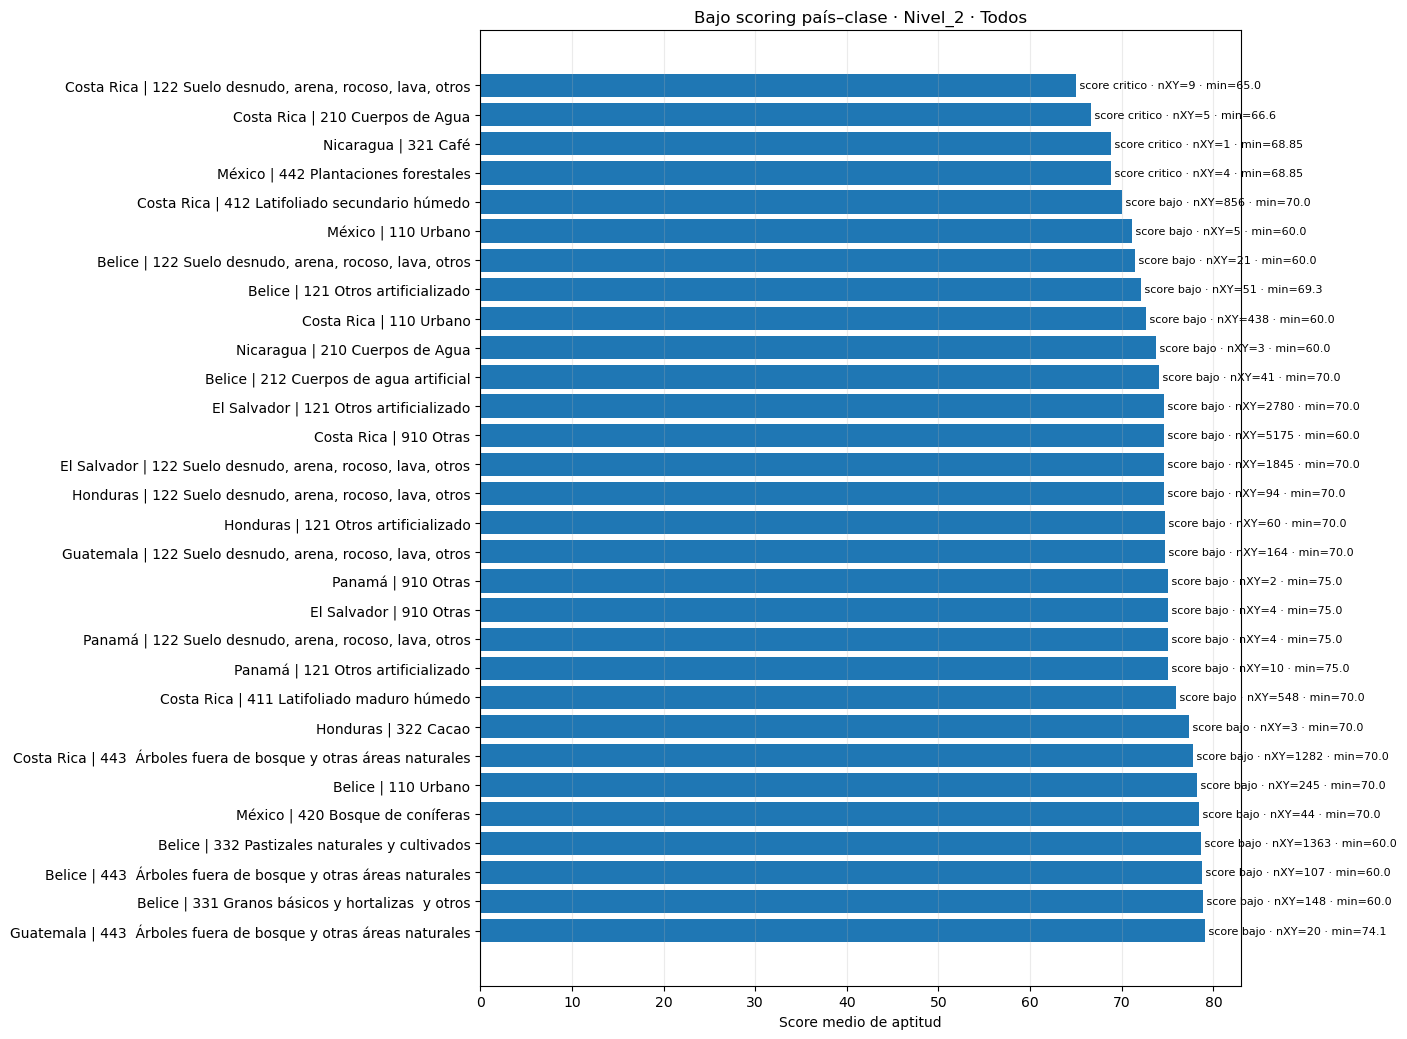

In [42]:
def plot_count_gaps(
    df_count: pd.DataFrame,
    level_name: str,
    top_n: int = TOP_N,
    country: str = "Todos",
    save: bool = True,
):
    data = df_count.copy()

    if country != "Todos":
        data = data[data["pais"] == country].copy()

    # Solo combinaciones con baja cantidad de puntos.
    data = data[data["estado_count"].isin([
        "baja cantidad de puntos critica",
        "baja cantidad de puntos",
    ])].copy()

    if data.empty:
        print("No hay combinaciones con baja cantidad de puntos para el filtro.")
        return

    # Valor visual:
    # - si n_xy = 0, usa n_xy_regional para que la barra sea visible;
    # - si n_xy > 0, usa n_xy nacional.
    data["valor_plot"] = np.where(
        data["n_xy"] == 0,
        data["n_xy_regional"],
        data["n_xy"]
    )

    data["tipo_plot"] = np.where(
        data["n_xy"] == 0,
        "sin grupos XY en el pais; se grafica soporte regional",
        "se grafica soporte nacional"
    )

    data = (
        data
        .sort_values(["n_xy", "valor_plot", "n_xy_regional"], ascending=[True, False, False])
        .head(top_n)
    )

    data = data.iloc[::-1].copy()

    labels = data.apply(lambda r: f"{r['pais']} | {r['clase']}", axis=1)

    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * len(data))))
    ax.barh(labels, data["valor_plot"])

    ax.set_xlabel(
        "Valor de priorización "
        "(nXY país si existe; nXY regional si no hay puntos en el país)"
    )
    ax.set_title(f"Baja cantidad de puntos país–clase · {level_name} · {country}")
    ax.grid(axis="x", alpha=0.25)

    for i, (_, row) in enumerate(data.iterrows()):
        if row["n_xy"] == 0:
            label = (
                f" baja cantidad de puntos · nXY país=0 · "
                f"reg={int(row['n_registros'])} · "
                f"nXY regional={int(row['n_xy_regional'])}"
            )
        else:
            label = (
                f" baja cantidad de puntos · "
                f"nXY país={int(row['n_xy'])} · "
                f"reg={int(row['n_registros'])} · "
                f"nXY regional={int(row['n_xy_regional'])}"
            )

        ax.text(
            row["valor_plot"],
            i,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()

    if save:
        suffix_country = "" if country == "Todos" else f"_{country.replace(' ', '_')}"
        out = OUT_FIGURES / f"10_baja_cantidad_puntos_top{top_n}_{level_name}{suffix_country}.png"
        fig.savefig(out, dpi=220, bbox_inches="tight")
        print("[OK]", out)

    plt.show()


def plot_score_gaps(
    df_score: pd.DataFrame,
    level_name: str,
    top_n: int = TOP_N,
    country: str = "Todos",
    save: bool = True,
):
    data = df_score.copy()

    if country != "Todos":
        data = data[data["pais"] == country].copy()

    subset = data[data["estado_score"].isin(["sin score", "score critico", "score bajo"])].copy()

    if subset.empty:
        subset = data.copy()

    subset = (
        subset
        .sort_values(["score_medio", "n_xy"], ascending=[True, True])
        .head(top_n)
    )

    if subset.empty:
        print("No hay datos de scoring para el filtro.")
        return

    subset = subset.iloc[::-1].copy()

    labels = subset.apply(lambda r: f"{r['pais']} | {r['clase']}", axis=1)

    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * len(subset))))

    ax.barh(labels, subset["score_medio"])

    ax.set_xlabel("Score medio de aptitud")
    ax.set_title(f"Bajo scoring país–clase · {level_name} · {country}")
    ax.grid(axis="x", alpha=0.25)

    for i, (_, row) in enumerate(subset.iterrows()):
        score_value = row["score_medio"]
        if pd.isna(score_value):
            score_value = 0

        ax.text(
            score_value,
            i,
            f" {row['estado_score']} · nXY={int(row['n_xy'])} · min={row['score_min']}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()

    if save:
        suffix_country = "" if country == "Todos" else f"_{country.replace(' ', '_')}"
        out = OUT_FIGURES / f"10_bajo_scoring_top{top_n}_{level_name}{suffix_country}.png"
        fig.savefig(out, dpi=220, bbox_inches="tight")
        print("[OK]", out)

    plt.show()


for level_name in levels.keys():
    plot_count_gaps(
        count_gaps[level_name],
        level_name=level_name,
        top_n=TOP_N,
        country="Todos",
        save=True,
    )

    plot_score_gaps(
        score_gaps[level_name],
        level_name=level_name,
        top_n=TOP_N,
        country="Todos",
        save=True,
    )


## 7. Plot interactivo corregido

In [43]:
# ============================================================
# PLOT INTERACTIVO CORREGIDO
# ============================================================

def safe_name(text):
    text = str(text).replace(" ", "_")
    text = re.sub(r"[^A-Za-z0-9_\-]+", "", text)
    return text[:120]


def get_all_countries():
    countries = set()

    for d in [count_gaps, score_gaps]:
        for _, df_tmp in d.items():
            if "pais" in df_tmp.columns:
                countries.update(df_tmp["pais"].dropna().astype(str).unique())

    return ["Todos"] + sorted(countries)


def prepare_plot_data(level, country, view, top_n):
    if view == "Baja cantidad de puntos":
        df_plot = count_gaps[level].copy()

        if country != "Todos":
            df_plot = df_plot[df_plot["pais"] == country].copy()

        df_plot = df_plot[df_plot["estado_count"].isin([
            "baja cantidad de puntos critica",
            "baja cantidad de puntos",
        ])].copy()

        if df_plot.empty:
            return df_plot, "valor_plot", "Valor de priorización", "count"

        df_plot["valor_plot"] = np.where(
            df_plot["n_xy"] == 0,
            df_plot["n_xy_regional"],
            df_plot["n_xy"]
        )

        df_plot = (
            df_plot
            .sort_values(["n_xy", "valor_plot", "n_xy_regional"], ascending=[True, False, False])
            .head(top_n)
        )

        return (
            df_plot,
            "valor_plot",
            "Valor de priorización: nXY país si existe; nXY regional si no hay puntos en el país",
            "count"
        )

    else:
        df_plot = score_gaps[level].copy()

        if country != "Todos":
            df_plot = df_plot[df_plot["pais"] == country].copy()

        df_priority = df_plot[df_plot["estado_score"].isin([
            "sin score", "score critico", "score bajo"
        ])].copy()

        if not df_priority.empty:
            df_plot = df_priority

        df_plot = (
            df_plot
            .sort_values(["score_medio", "n_xy"], ascending=[True, True])
            .head(top_n)
        )

        return df_plot, "score_medio", "Score medio de aptitud", "score"


def draw_plot(level, country, view, top_n, save=False):
    df_plot, metric_col, xlabel, mode = prepare_plot_data(level, country, view, top_n)

    if df_plot.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.text(
            0.5, 0.5,
            "No hay combinaciones país–clase para el filtro seleccionado.",
            ha="center", va="center", fontsize=12
        )
        ax.axis("off")
        plt.show()
        return None

    df_plot = df_plot.iloc[::-1].copy()

    labels = df_plot.apply(
        lambda r: f"{r['pais']} | {r['clase']}",
        axis=1
    )

    fig_height = max(6, 0.38 * len(df_plot))
    fig, ax = plt.subplots(figsize=(15, fig_height))

    ax.barh(labels, df_plot[metric_col].fillna(0))
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel(xlabel)

    title = f"{view} · {level} · País: {country} · Top {top_n}"
    ax.set_title(title)

    for i, (_, row) in enumerate(df_plot.iterrows()):
        val = row[metric_col]

        if mode == "count":
            if row["n_xy"] == 0:
                txt = (
                    f" baja cantidad de puntos · nXY país=0 · "
                    f"reg={int(row['n_registros'])} · "
                    f"nXY regional={int(row['n_xy_regional'])}"
                )
            else:
                txt = (
                    f" baja cantidad de puntos · "
                    f"nXY país={int(row['n_xy'])} · "
                    f"reg={int(row['n_registros'])} · "
                    f"nXY regional={int(row['n_xy_regional'])}"
                )

            x_text = val

        else:
            score_min = row["score_min"] if "score_min" in row else np.nan
            txt = (
                f" {row['estado_score']} · "
                f"nXY={int(row['n_xy'])} · "
                f"score min={score_min}"
            )

            x_text = val if not np.isnan(val) else 0

        ax.text(
            x_text,
            i,
            " " + txt,
            va="center",
            fontsize=8
        )

    plt.tight_layout()

    if save:
        OUT_FIGURES.mkdir(parents=True, exist_ok=True)

        out_name = (
            f"10_plot_interactivo_"
            f"{safe_name(view)}_"
            f"{safe_name(level)}_"
            f"{safe_name(country)}_"
            f"top{top_n}.png"
        )

        out_path = OUT_FIGURES / out_name
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
        print(f"[OK] Figura guardada: {out_path}")

    plt.show()
    return fig


if not HAS_WIDGETS:
    print("ipywidgets no está disponible. Instalar con: conda install -c conda-forge ipywidgets")
else:
    level_options = list(count_gaps.keys())

    level_w = widgets.Dropdown(
        options=level_options,
        value="Nivel_2" if "Nivel_2" in level_options else level_options[0],
        description="Nivel:",
        layout=widgets.Layout(width="260px")
    )

    country_w = widgets.Dropdown(
        options=get_all_countries(),
        value="Todos",
        description="País:",
        layout=widgets.Layout(width="320px")
    )

    view_w = widgets.Dropdown(
        options=["Baja cantidad de puntos", "Bajo scoring"],
        value="Baja cantidad de puntos",
        description="Vista:",
        layout=widgets.Layout(width="320px")
    )

    top_w = widgets.IntSlider(
        value=30,
        min=10,
        max=80,
        step=5,
        description="Top N:",
        continuous_update=False,
        layout=widgets.Layout(width="420px")
    )

    save_btn = widgets.Button(
        description="Guardar PNG",
        button_style="success",
        tooltip="Exporta la figura actual a outputs/figures",
        icon="save"
    )

    out = widgets.Output()

    def update_plot(*args):
        with out:
            clear_output(wait=True)
            draw_plot(
                level=level_w.value,
                country=country_w.value,
                view=view_w.value,
                top_n=top_w.value,
                save=False
            )

    def save_current_plot(_):
        with out:
            clear_output(wait=True)
            draw_plot(
                level=level_w.value,
                country=country_w.value,
                view=view_w.value,
                top_n=top_w.value,
                save=True
            )

    level_w.observe(update_plot, names="value")
    country_w.observe(update_plot, names="value")
    view_w.observe(update_plot, names="value")
    top_w.observe(update_plot, names="value")
    save_btn.on_click(save_current_plot)

    controls = widgets.VBox([
        widgets.HBox([level_w, country_w]),
        widgets.HBox([view_w, top_w, save_btn])
    ])

    display(controls, out)

    update_plot()

## Interpretación de la gráfica interactiva:

# nXY país = cantidad de grupos XY únicos en ese país para esa clase
# reg = cantidad de registros originales asociados a esos grupos XY
# nXY regional = cantidad de grupos XY únicos de esa clase en toda la región

### Ejemplo de caso de Belice, por si alguien quiere tenerlo más clarito:

# En Belice, para la clase 'Palma aceitera':

# Para ese país y esa clase solo hay 6 ubicaciones únicas evaluables, aunque esas 6 ubicaciones provienen de 12 registros originales. 
# Sin embargo, esa misma clase tiene 77,460 grupos XY en toda la región.

Output()

Codes más simples de entender, los plots

In [44]:

import re
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    raise ImportError(
        "Falta ipywidgets. Instalar con:\n"
        "conda install -c conda-forge ipywidgets\n"
        "o\n"
        "pip install ipywidgets"
    )


# ------------------------------------------------------------
# Validaciones
# ------------------------------------------------------------
required_vars = ["count_gaps", "score_gaps", "OUT_FIGURES"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    raise RuntimeError(
        "Faltan variables necesarias: "
        + ", ".join(missing)
        + "\nEjecutá primero las celdas que leen el GPKG y generan count_gaps / score_gaps."
    )


# ------------------------------------------------------------
# Utilidades
# ------------------------------------------------------------
def safe_name(text):
    text = str(text).replace(" ", "_")
    text = re.sub(r"[^A-Za-z0-9_\-]+", "", text)
    return text[:120]


def get_all_countries():
    countries = set()

    for d in [count_gaps, score_gaps]:
        for _, df_tmp in d.items():
            if "pais" in df_tmp.columns:
                countries.update(df_tmp["pais"].dropna().astype(str).unique())

    return ["Todos"] + sorted(countries)


def prepare_plot_data(level, country, view, order_mode, top_n):
    if view == "Cantidad de puntos":
        df_plot = count_gaps[level].copy()

        if country != "Todos":
            df_plot = df_plot[df_plot["pais"] == country].copy()

        # Solo clases presentes en el país.
        # Se excluyen ceros porque este gráfico es de cantidad real de puntos.
        df_plot = df_plot[df_plot["n_xy"] > 0].copy()

        if df_plot.empty:
            return df_plot, "n_xy", "Número de puntos / grupos XY", "count"

        if order_mode == "Menor cantidad":
            df_plot = (
                df_plot
                .sort_values(["n_xy", "clase"], ascending=[True, True])
                .head(top_n)
            )
        else:
            df_plot = (
                df_plot
                .sort_values(["n_xy", "clase"], ascending=[False, True])
                .head(top_n)
            )

        return df_plot, "n_xy", "Número de puntos / grupos XY", "count"

    else:
        df_plot = score_gaps[level].copy()

        if country != "Todos":
            df_plot = df_plot[df_plot["pais"] == country].copy()

        # Solo combinaciones con datos.
        df_plot = df_plot[df_plot["n_xy"] > 0].copy()

        if df_plot.empty:
            return df_plot, "score_medio", "Score medio de aptitud", "score"

        # El objetivo aquí es ver las clases con peor scoring.
        df_plot = (
            df_plot
            .sort_values(["score_medio", "n_xy"], ascending=[True, True])
            .head(top_n)
        )

        return df_plot, "score_medio", "Score medio de aptitud", "score"


def draw_plot(level, country, view, order_mode, top_n, save=False):
    df_plot, metric_col, xlabel, mode = prepare_plot_data(
        level=level,
        country=country,
        view=view,
        order_mode=order_mode,
        top_n=top_n
    )

    if df_plot.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.text(
            0.5, 0.5,
            "No hay datos para el filtro seleccionado.",
            ha="center", va="center", fontsize=12
        )
        ax.axis("off")
        plt.show()
        return None

    df_plot = df_plot.iloc[::-1].copy()

    labels = df_plot.apply(
        lambda r: f"{r['pais']} | {r['clase']}",
        axis=1
    )

    fig_height = max(6, 0.38 * len(df_plot))
    fig, ax = plt.subplots(figsize=(15, fig_height))

    ax.barh(labels, df_plot[metric_col].fillna(0))
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel(xlabel)

    if view == "Cantidad de puntos":
        title = f"Cantidad de puntos por clase y país · {level} · País: {country} · {order_mode} · Top {top_n}"
    else:
        title = f"Clases con scoring más bajo por país · {level} · País: {country} · Top {top_n}"

    ax.set_title(title)

    for i, (_, row) in enumerate(df_plot.iterrows()):
        val = row[metric_col]

        if mode == "count":
            txt = (
                f" puntos={int(row['n_xy']):,} · "
                f"registros={int(row['n_registros']):,}"
            )
            x_text = val

        else:
            score_min = row["score_min"] if "score_min" in row else np.nan
            txt = (
                f" score={row['score_medio']:.2f} · "
                f"puntos={int(row['n_xy']):,} · "
                f"min={score_min}"
            )
            x_text = val if not np.isnan(val) else 0

        ax.text(
            x_text,
            i,
            " " + txt,
            va="center",
            fontsize=8
        )

    plt.tight_layout()

    if save:
        OUT_FIGURES.mkdir(parents=True, exist_ok=True)

        out_name = (
            f"10_plot_interactivo_"
            f"{safe_name(view)}_"
            f"{safe_name(order_mode)}_"
            f"{safe_name(level)}_"
            f"{safe_name(country)}_"
            f"top{top_n}.png"
        )

        out_path = OUT_FIGURES / out_name
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
        print(f"[OK] Figura guardada: {out_path}")

    plt.show()
    return fig


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------
level_options = list(count_gaps.keys())

level_w = widgets.Dropdown(
    options=level_options,
    value="Nivel_2" if "Nivel_2" in level_options else level_options[0],
    description="Nivel:",
    layout=widgets.Layout(width="260px")
)

country_w = widgets.Dropdown(
    options=get_all_countries(),
    value="Todos",
    description="País:",
    layout=widgets.Layout(width="320px")
)

view_w = widgets.Dropdown(
    options=[
        "Cantidad de puntos",
        "Scoring más bajo",
    ],
    value="Cantidad de puntos",
    description="Vista:",
    layout=widgets.Layout(width="320px")
)

order_w = widgets.Dropdown(
    options=[
        "Menor cantidad",
        "Mayor cantidad",
    ],
    value="Menor cantidad",
    description="Orden:",
    layout=widgets.Layout(width="300px")
)

top_w = widgets.IntSlider(
    value=30,
    min=10,
    max=80,
    step=5,
    description="Top N:",
    continuous_update=False,
    layout=widgets.Layout(width="420px")
)

save_btn = widgets.Button(
    description="Guardar PNG",
    button_style="success",
    tooltip="Exporta la figura actual a outputs/figures",
    icon="save"
)

out = widgets.Output()


def update_plot(*args):
    with out:
        clear_output(wait=True)

        # En scoring, el orden siempre es de menor a mayor score.
        # El selector de orden solo aplica a cantidad de puntos.
        current_order = order_w.value
        if view_w.value == "Scoring más bajo":
            current_order = "Menor cantidad"

        draw_plot(
            level=level_w.value,
            country=country_w.value,
            view=view_w.value,
            order_mode=current_order,
            top_n=top_w.value,
            save=False
        )


def save_current_plot(_):
    with out:
        clear_output(wait=True)

        current_order = order_w.value
        if view_w.value == "Scoring más bajo":
            current_order = "Menor cantidad"

        draw_plot(
            level=level_w.value,
            country=country_w.value,
            view=view_w.value,
            order_mode=current_order,
            top_n=top_w.value,
            save=True
        )


level_w.observe(update_plot, names="value")
country_w.observe(update_plot, names="value")
view_w.observe(update_plot, names="value")
order_w.observe(update_plot, names="value")
top_w.observe(update_plot, names="value")
save_btn.on_click(save_current_plot)

controls = widgets.VBox([
    widgets.HBox([level_w, country_w]),
    widgets.HBox([view_w, order_w, top_w, save_btn])
])

display(controls, out)

update_plot()

Output()